# Detección de Amenazas Internas: Análisis de Comportamiento de Usuarios

## Fundamentos del Análisis de Comportamiento (UBA)

El **User Behavior Analytics** detecta cambios anómalos en patrones de usuarios,
identificando cuentas comprometidas y amenazas internas. Se establecen perfiles estadísticos
base y se detectan desviaciones significativas.

### Técnicas implementadas
- **Perfiles estadísticos**: media, desviación estándar, percentiles por usuario
- **Scoring de anomalía**: Z-score, distancia a la media histórica
- **Clustering**: K-Means para patrones de comportamiento
- **Detección de reglas**: horas inusuales, IPs nuevas, volumen anómalo


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import Counter

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
print("Importaciones OK")

Importaciones OK


## 1. Generación de logs de actividad de usuarios

In [2]:
def generar_logs_usuarios(n_users=10, n_logs_por_user=90, seed=42):
    """
    Genera registros de actividad diaria para múltiples usuarios.
    Cada registro representa una sesión de trabajo.
    """
    rng = np.random.default_rng(seed)
    usuarios = [f"user_{chr(65+i)}" for i in range(n_users)]  # user_A ... user_J
    
    registros = []
    for user in usuarios:
        # Perfil de referencia por usuario (cada uno tiene hábitos distintos)
        hora_media   = rng.integers(7, 11)        # entre 7 AM y 11 AM
        bytes_media  = rng.integers(50_000, 200_000)
        ip_principal = f"10.0.{rng.integers(1,5)}.{rng.integers(1,255)}"
        
        for _ in range(n_logs_por_user):
            registros.append({
                "user":           user,
                "hora_login":     float(hora_media) + rng.normal(0, 0.8),
                "bytes_sent":     max(0, bytes_media + rng.normal(0, bytes_media*0.3)),
                "ip_origen":      ip_principal if rng.random() > 0.03 else  # 3% IPs raras
                                  f"45.{rng.integers(1,255)}.{rng.integers(1,255)}.1",
                "failed_logins":  int(rng.poisson(0.5)),
                "archivos_accedidos": int(rng.poisson(20)),
            })
    
    df = pd.DataFrame(registros)
    # Añadir algunos eventos anómalos explícitos
    anomalos = pd.DataFrame([
        # Acceso nocturno + IP externa + volumen alto
        {"user": "user_A", "hora_login": 3.2,  "bytes_sent": 5_000_000,
         "ip_origen": "195.20.14.10", "failed_logins": 8, "archivos_accedidos": 300},
        {"user": "user_C", "hora_login": 2.8,  "bytes_sent": 8_000_000,
         "ip_origen": "87.91.11.55",  "failed_logins": 0, "archivos_accedidos": 500},
        {"user": "user_F", "hora_login": 9.1,  "bytes_sent": 15_000_000,
         "ip_origen": "10.0.2.15",    "failed_logins": 0, "archivos_accedidos": 50},
    ])
    
    return pd.concat([df, anomalos], ignore_index=True)

logs = generar_logs_usuarios()
print(f"Total de registros: {len(logs)}")
print(f"Usuarios únicos:    {logs.user.nunique()}")
logs.describe()

Total de registros: 903
Usuarios únicos:    10


,hora_login,bytes_sent,failed_logins,archivos_accedidos
count,903.000000,9.030000e+02,903.000000,903.000000
mean,7.978536,1.587929e+05,0.529347,20.765227
std,1.300020,5.855713e+05,0.758523,19.028984
min,2.800000,8.021593e+03,0.000000,9.000000
25%,7.012175,8.007043e+04,0.000000,17.000000
50%,7.916012,1.197175e+05,0.000000,20.000000
75%,8.911924,1.684892e+05,1.000000,23.000000
max,12.168596,1.500000e+07,8.000000,500.000000


## 2. Construcción de perfiles de usuario

In [3]:
def construir_perfil(logs: pd.DataFrame, usuario: str) -> dict:
    """Calcula estadísticas históricas del comportamiento de un usuario."""
    datos = logs[logs.user == usuario]
    ips_conteo = Counter(datos.ip_origen)
    
    return {
        "usuario"             : usuario,
        "hora_media"          : datos.hora_login.mean(),
        "hora_std"            : datos.hora_login.std(),
        "bytes_media"         : datos.bytes_sent.mean(),
        "bytes_std"           : datos.bytes_sent.std(),
        "ips_frecuentes"      : set(k for k, v in ips_conteo.items()
                                    if v / len(datos) >= 0.05),
        "failed_logins_p95"   : datos.failed_logins.quantile(0.95),
        "archivos_p95"        : datos.archivos_accedidos.quantile(0.95),
    }

# Construir perfiles para todos los usuarios
# Usamos solo datos "normales" (excluimos los anómalos añadidos)
logs_entrenamiento = logs.head(-3)  # excluir las 3 filas anómalas

perfiles = {}
for user in logs_entrenamiento.user.unique():
    perfiles[user] = construir_perfil(logs_entrenamiento, user)

# Mostrar perfil de un usuario de ejemplo
p = perfiles["user_A"]
print(f"Perfil de {p['usuario']}:")
for k, v in p.items():
    if k != "usuario":
        print(f"  {k:<22}: {v}")

Perfil de user_A:
  hora_media            : 6.965526744859728
  hora_std              : 0.8302176027609518
  bytes_media           : 165140.387324972
  bytes_std             : 51443.424865222274
  ips_frecuentes        : {'10.0.3.112'}
  failed_logins_p95     : 2.0
  archivos_p95          : 27.549999999999997


## 3. Detección de comportamiento anómalo mediante Z-score

In [4]:
def detectar_anomalias(evento: dict, perfil: dict, umbral_z: float = 3.0) -> list:
    """
    Compara un evento con el perfil del usuario.
    Genera alertas cuando el z-score supera el umbral.
    """
    alertas = []

    # 1. Hora de inicio de sesión inusual
    if perfil["hora_std"] > 0:
        z_hora = abs(evento["hora_login"] - perfil["hora_media"]) / perfil["hora_std"]
        if z_hora > umbral_z:
            alertas.append(
                f"Hora inusual (z={z_hora:.1f}): {evento['hora_login']:.1f}h "
                f"[habitual: {perfil['hora_media']:.1f}h ± {perfil['hora_std']:.1f}h]"
            )

    # 2. IP desconocida
    if evento["ip_origen"] not in perfil["ips_frecuentes"]:
        alertas.append(f"IP no habitual: {evento['ip_origen']}")

    # 3. Volumen de datos inusual
    if perfil["bytes_std"] > 0:
        z_bytes = (evento["bytes_sent"] - perfil["bytes_media"]) / perfil["bytes_std"]
        if z_bytes > umbral_z:
            alertas.append(
                f"Volumen inusual (z={z_bytes:.1f}): {evento['bytes_sent']:,.0f} bytes"
            )

    # 4. Intentos fallidos
    if evento["failed_logins"] > perfil["failed_logins_p95"]:
        alertas.append(
            f"Accesos fallidos elevados: {evento['failed_logins']} "
            f"(P95 = {perfil['failed_logins_p95']:.0f})"
        )

    return alertas

# Evaluar los 3 eventos anómalos
eventos_test = logs.tail(3)[["user", "hora_login", "bytes_sent",
                               "ip_origen", "failed_logins"]].to_dict("records")

print("=" * 60)
for evento in eventos_test:
    usuario = evento["user"]
    alertas = detectar_anomalias(evento, perfiles[usuario])
    print(f"\nUsuario: {usuario}")
    if alertas:
        for a in alertas:
            print(f"  [!] {a}")
    else:
        print("  Comportamiento normal.")


Usuario: user_A
  [!] Hora inusual (z=4.5): 3.2h [habitual: 7.0h ± 0.8h]
  [!] IP no habitual: 195.20.14.10
  [!] Volumen inusual (z=94.0): 5,000,000 bytes
  [!] Accesos fallidos elevados: 8 (P95 = 2)

Usuario: user_C
  [!] Hora inusual (z=8.7): 2.8h [habitual: 10.0h ± 0.8h]
  [!] IP no habitual: 87.91.11.55
  [!] Volumen inusual (z=146.4): 8,000,000 bytes

Usuario: user_F
  [!] IP no habitual: 10.0.2.15
  [!] Volumen inusual (z=580.1): 15,000,000 bytes


## 4. Clustering de patrones de comportamiento con K-Means

Agrupamos a los usuarios en clusters según su comportamiento agregado.
Esto permite identificar grupos de riesgo similares.

In [5]:
# Construir tabla de características por usuario (resumen estadístico)
resumen = logs_entrenamiento.groupby("user").agg(
    hora_media    =("hora_login",          "mean"),
    hora_std      =("hora_login",          "std"),
    bytes_media   =("bytes_sent",          "mean"),
    bytes_max     =("bytes_sent",          "max"),
    failed_media  =("failed_logins",       "mean"),
    archivos_media=("archivos_accedidos",  "mean"),
).reset_index()

# Escalar características
X_cluster = resumen.drop("user", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
resumen["cluster"] = kmeans.fit_predict(X_scaled)

print("Usuarios por cluster:")
print(resumen[["user", "cluster", "hora_media", "bytes_media"]]
      .sort_values("cluster").to_string(index=False))

Usuarios por cluster:
  user  cluster  hora_media   bytes_media
user_A        0    6.965527 165140.387325
user_H        0    8.905463 193558.425021
user_G        0    6.976653 168702.329189
user_E        0    6.951671 111003.047271
user_J        0    8.094359 146027.893856
user_C        1    9.956712 158259.225928
user_D        1    9.130358 114681.127286
user_B        2    7.939510  65260.607207
user_F        2    7.935122  75959.645956
user_I        2    7.028154  83518.077664


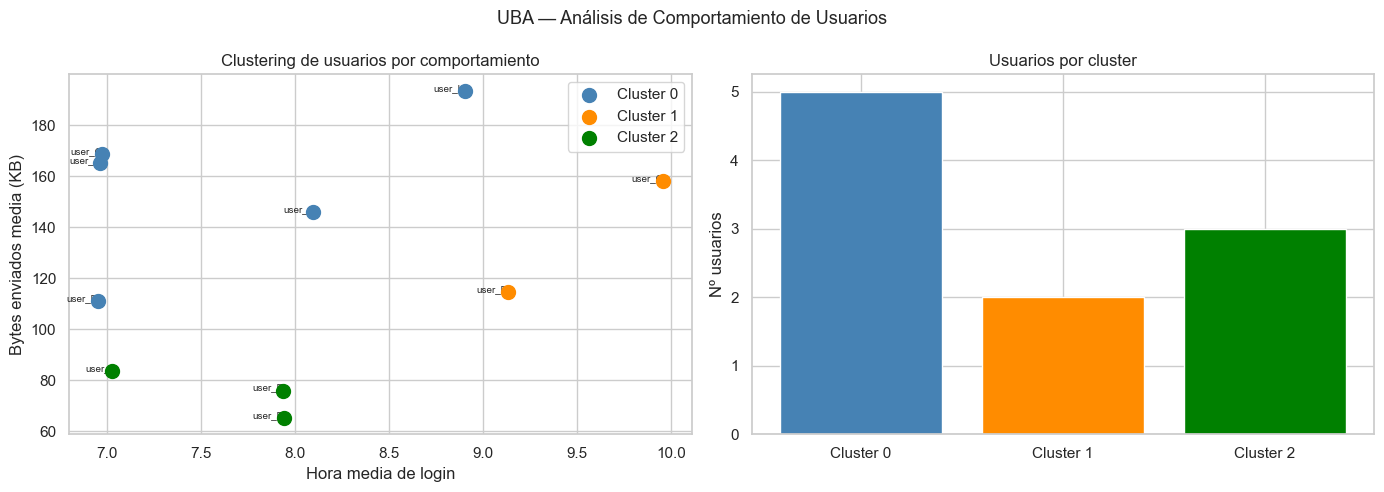


✓ Cuaderno 5 completado.


In [6]:
# Visualización de clusters
colores_cluster = ["steelblue", "darkorange", "green"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hora vs bytes
for c in range(3):
    mask = resumen.cluster == c
    axes[0].scatter(resumen[mask].hora_media,
                    resumen[mask].bytes_media / 1000,
                    color=colores_cluster[c], s=100, label=f"Cluster {c}", zorder=5)
    for _, row in resumen[mask].iterrows():
        axes[0].annotate(row.user, (row.hora_media, row.bytes_media/1000),
                         fontsize=7, ha="right")

axes[0].set_xlabel("Hora media de login")
axes[0].set_ylabel("Bytes enviados media (KB)")
axes[0].set_title("Clustering de usuarios por comportamiento")
axes[0].legend()

# Distribución por cluster
cluster_counts = resumen.cluster.value_counts().sort_index()
axes[1].bar([f"Cluster {c}" for c in cluster_counts.index],
            cluster_counts.values,
            color=colores_cluster[:len(cluster_counts)])
axes[1].set_title("Usuarios por cluster")
axes[1].set_ylabel("Nº usuarios")

plt.suptitle("UBA — Análisis de Comportamiento de Usuarios", fontsize=13)
plt.tight_layout()
plt.show()

print("\n✓ Cuaderno 5 completado.")